## EDA: 🏥 Hospital Cost & Patient Resource Utilization Analysis

</div>

<img src="https://images.unsplash.com/photo-1587351021759-3e566b6af7cc" width="70%">

* [Image Source](https://images.unsplash.com/photo-1587351021759-3e566b6af7cc)

Hello 👋

This Project explores the Hospital cost and Patient Resource Analysis in the New York City using publicly available data in kaggle.  
<strong>The goal of this Exploratory Data Analysis (EDA) is to understand the Hospital Treatment Cost, Demographic Patterns, and Risk Factors for HealthCare Expenses.</strong>
</p>

## 📊 Project Goal

* The goal of this project is to analyze hospital inpatient cost transparency data to understand:
* How hospital treatment charges vary across diagnoses and hospitals
* How severity of illness affects healthcare cost/s
* Which hospitals handle the highest patient volume
* The relationship between hospital costs, charges, and patient discharges
* Key drivers of hospital resource utilization

By analyzing these patterns, the project aims to identify <span style="color:Yellow">cost drivers, hospital workload distribution, and healthcare utilization trends</span> that can help healthcare administrators optimize hospital operations.

# Data Source↓
* [Hospital Inpatient Cost Transparency](https://www.kaggle.com/datasets/wajahat1064/hospital-inpatient-cost-data-by-new-york-state)


## 📚 Table of Contents


1. [Introduction](#introduction)
2. [Dataset Overview](#dataset-overview)
3. [Data Cleaning](#data-cleaning)
4. [Univariate Analysis](#univariate-analysis)
5. [Bivariate Analysis](#bivariate-analysis)
6. [Hospital Cost Analysis](#hospital-cost-analysis)
7. [Patient Resource Utilization](#patient-resource-utilization)
8. [Key Insights](#key-insights)
9. [Conclusion](#conclusion)

## About New York City


New York City is one of the largest metropolitan healthcare hubs in the United States, serving millions of residents through a vast network of hospitals and medical facilities.  
With a diverse population and varying healthcare demands, analyzing hospital cost and patient resource utilization is crucial for improving healthcare efficiency.  
This analysis explores patterns in treatment costs, hospital stays, and resource allocation across healthcare institutions in New York City.  
Understanding these patterns can help healthcare administrators optimize hospital operations and improve patient care outcomes.

## 🏥 Introduction

Healthcare systems generate massive amounts of data related to:

- Patient admissions
- Medical procedures
- Hospital stays
- Treatment costs

Analyzing hospital inpatient discharge data can provide insights into:

✔ Hospital cost distribution  
✔ Resource utilization patterns  
✔ Patient demographics  
✔ Cost drivers in healthcare systems

These insights can help healthcare administrators **improve hospital efficiency and reduce operational costs.**

## 📊 Dataset Overview


The dataset contains hospital inpatient discharge records including, patient demographics, diagnosis details, treatment procedures, and hospital costs.

| Column | Description |
|------|-------------|
| Year | Year of Discharge |
| Facility Name | Hospital Name |
| APR DRG Description | Diagnosis / Treatment Type |
| APR Severity of Illness Description | Severity Level |
| Discharges | Number of Patients |
| Mean Charge | Average Hospital Charge |
| Median Charge | Median Hospital Charge |
| Mean Cost | Average Hospital Cost |
| Median Cost | Median Hospital Cost |

This dataset allows us to analyze **hospital costs and healthcare resource utilization patterns.**

## 🏥 Import Libraries

The following Python libraries are used in this analysis:

- **NumPy** for numerical computation
- **Pandas** for data manipulation
- **Matplotlib & Seaborn** for data visualization

In [7]:
import numpy as np
import pandas as pd

pd.options.display.float_format = '{:.2f}'.format

import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Dataset

df = pd.read_csv("D:\\Python-Libraries for Data Analysis\\00_Python_Projects_Files\\Hospital_Inpatient_Cost_Transparency__Beginning_2009_20240726.csv")
df

,Year,Facility Id,Facility Name,APR DRG Code,APR Severity of Illness Code,APR DRG Description,APR Severity of Illness Description,APR Medical Surgical Code,APR Medical Surgical Description,Discharges,Mean Charge,Median Charge,Mean Cost,Median Cost
0,2016,4,Albany Memorial Hospital,194,1,Heart Failure,Minor,M,Medical,2,8375.41,8375.41,3585.05,3585.05
1,2016,4,Albany Memorial Hospital,194,2,Heart Failure,Moderate,M,Medical,40,14029.82,12176.95,6182.67,5253.15
2,2016,4,Albany Memorial Hospital,194,3,Heart Failure,Major,M,Medical,70,23921.77,20229.81,11149.49,9068.10
3,2016,4,Albany Memorial Hospital,194,4,Heart Failure,Extreme,M,Medical,12,51260.45,35210.82,26081.70,15230.62
4,2016,4,Albany Memorial Hospital,196,4,Cardiac Arrest,Extreme,M,Medical,1,25357.84,25357.84,7791.75,7791.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1081667,2017,1738,Richmond University Medical Center,956,0,Ungroupable,Not Applicable,U,Other,1,18638.72,18638.72,4059.61,4059.61
1081668,2017,1740,Staten Island University Hosp-North,956,0,Ungroupable,Not Applicable,U,Other,1,114881.87,114881.87,74043.18,74043.18
1081669,2017,3058,Montefiore Med Center - Jack D Weiler Hosp of ...,956,0,Ungroupable,Not Applicable,U,Other,1,483596.29,483596.29,70046.24,70046.24
1081670,2017,3376,Cohen Children's Medical Center,956,0,Ungroupable,Not Applicable,U,Other,9,139202.90,29729.36,22991.41,4805.87


In [8]:
# Filtered dataset Where we dropped Other sections

filtered_data = df[df['APR Medical Surgical Description']!='Other']
filtered_data

,Year,Facility Id,Facility Name,APR DRG Code,APR Severity of Illness Code,APR DRG Description,APR Severity of Illness Description,APR Medical Surgical Code,APR Medical Surgical Description,Discharges,Mean Charge,Median Charge,Mean Cost,Median Cost
0,2016,4,Albany Memorial Hospital,194,1,Heart Failure,Minor,M,Medical,2,8375.41,8375.41,3585.05,3585.05
1,2016,4,Albany Memorial Hospital,194,2,Heart Failure,Moderate,M,Medical,40,14029.82,12176.95,6182.67,5253.15
2,2016,4,Albany Memorial Hospital,194,3,Heart Failure,Major,M,Medical,70,23921.77,20229.81,11149.49,9068.10
3,2016,4,Albany Memorial Hospital,194,4,Heart Failure,Extreme,M,Medical,12,51260.45,35210.82,26081.70,15230.62
4,2016,4,Albany Memorial Hospital,196,4,Cardiac Arrest,Extreme,M,Medical,1,25357.84,25357.84,7791.75,7791.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1081587,2017,3376,Cohen Children's Medical Center,952,3,Nonextensive procedure unrelated to principal ...,Major,P,Surgical,5,171291.48,130663.28,50117.97,38399.06
1081588,2017,3975,New York Presbyterian Hospital - Allen Hospital,952,1,Nonextensive procedure unrelated to principal ...,Minor,P,Surgical,2,34744.89,34744.89,9966.36,9966.36
1081589,2017,3975,New York Presbyterian Hospital - Allen Hospital,952,2,Nonextensive procedure unrelated to principal ...,Moderate,P,Surgical,5,91317.24,109158.47,23795.42,28182.18
1081590,2017,3975,New York Presbyterian Hospital - Allen Hospital,952,3,Nonextensive procedure unrelated to principal ...,Major,P,Surgical,5,479554.58,131351.54,118723.21,32313.32


## Basic Data Understanding

- Check dataset shape
- Inspect column types
- Summary Statistics

In [9]:
# Basic Data Understanding 

# 1. Checking the dataset shape

df.shape

(1081672, 14)

In [10]:
# 2. Inspect Column Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1081672 entries, 0 to 1081671
Data columns (total 14 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   Year                                 1081672 non-null  int64  
 1   Facility Id                          1081672 non-null  int64  
 2   Facility Name                        1081672 non-null  object 
 3   APR DRG Code                         1081672 non-null  int64  
 4   APR Severity of Illness Code         1081672 non-null  int64  
 5   APR DRG Description                  1081672 non-null  object 
 6   APR Severity of Illness Description  1081462 non-null  object 
 7   APR Medical Surgical Code            1081330 non-null  object 
 8   APR Medical Surgical Description     1081672 non-null  object 
 9   Discharges                           1081672 non-null  int64  
 10  Mean Charge                          1081672 non-null  float64
 11

In [11]:
# 3. Summary Statistics

df.describe().round(2)

,Year,Facility Id,APR DRG Code,APR Severity of Illness Code,Discharges,Mean Charge,Median Charge,Mean Cost,Median Cost
count,1081672.00,1081672.00,1081672.00,1081672.00,1081672.00,1081672.00,1081672.00,1081672.00,1081672.00
mean,2012.88,939.51,377.28,2.34,20.56,49847.99,45682.44,18495.54,16813.28
std,2.59,649.02,247.31,1.04,81.70,83314.11,78891.66,33412.01,31605.88
min,2009.00,1.00,1.00,0.00,1.00,0.01,0.01,0.00,0.00
25%,2011.00,513.00,192.00,1.00,2.00,14246.19,12878.00,5671.94,5054.48
50%,2013.00,895.00,313.00,2.00,5.00,27078.76,24392.58,10140.49,8987.15
75%,2015.00,1306.00,560.00,3.00,16.00,53838.23,48621.70,19854.98,17783.94
max,2017.00,9431.00,956.00,4.00,6938.00,7456978.85,7456978.85,7683085.80,7683085.80


## 🧹 Data Cleaning

Before performing analysis, the dataset needs to be prepared by if neccessary:

✔ Handling missing values  
✔ Removing duplicates  
✔ Converting data types  
✔ Standardizing column names

Data cleaning ensures **accurate and reliable analysis results.**

In [12]:
# Performing Various Data Cleaning Process

# 1. Checking Null Values in the Dataset

df.isnull().sum()

Year                                     0
Facility Id                              0
Facility Name                            0
APR DRG Code                             0
APR Severity of Illness Code             0
APR DRG Description                      0
APR Severity of Illness Description    210
APR Medical Surgical Code              342
APR Medical Surgical Description         0
Discharges                               0
Mean Charge                              0
Median Charge                            0
Mean Cost                                0
Median Cost                              0
dtype: int64

In [13]:
# 2. Filling null values

df.fillna("Not Present",inplace = True)

In [14]:
# Rechecking the Null Values

df.isnull().sum()

Year                                   0
Facility Id                            0
Facility Name                          0
APR DRG Code                           0
APR Severity of Illness Code           0
APR DRG Description                    0
APR Severity of Illness Description    0
APR Medical Surgical Code              0
APR Medical Surgical Description       0
Discharges                             0
Mean Charge                            0
Median Charge                          0
Mean Cost                              0
Median Cost                            0
dtype: int64

In [15]:
# 2. Checking for duplicates rows

df.duplicated().sum()

np.int64(0)

## 📈 Univariate Analysis 

Univariate analysis focuses on **analyzing individual variables** in the dataset.

Key questions explored:

- What is the distribution of hospital mean charges across all treatments?
- What is the distribution of hospital costs for inpatient procedures?
- Which diagnosis categories appear most frequently in hospital discharges?
- What is the distribution of patient discharge volumes across hospitals?
- How are severity levels of illness distributed among hospital patients?

This analysis helps understand **basic patterns in healthcare data.**

In [16]:
# Univariate Analysis

# Here I grouped the data according to the 'APR Medical Surgical Description' with 'Mean charge' and perform sum operation.

# 1. What is the distribution of hospital mean charges across all treatments?

Mean_Charges = df.groupby("APR Medical Surgical Description")['Mean Charge'].sum()
Mean_Charges = Mean_Charges.reindex(['Medical','Surgical','Other'])
Mean_Charges_df = Mean_Charges.reset_index()                                           # Here we performing reset_index() because earlier it was in a series but to conver it into datafram
Mean_Charges_df = Mean_Charges_df.round(2)
Mean_Charges_df

,APR Medical Surgical Description,Mean Charge
0,Medical,27452357978.63
1,Surgical,26425939577.96
2,Other,40876267.62


C:\Users\dhamm\AppData\Local\Temp\ipykernel_17964\227102433.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = Mean_Charges_df, x = "APR Medical Surgical Description", y = "Mean Charge",palette= ['Red','Blue','Green'])


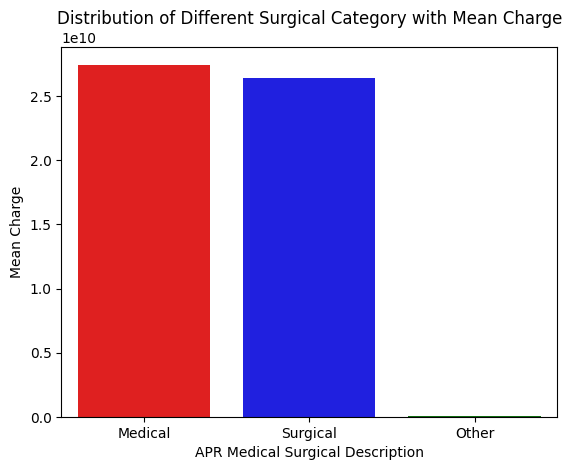

In [17]:
# Here I used BarPlot

# 1. What is the distribution of hospital mean charges across all treatments?

sns.barplot(data = Mean_Charges_df, x = "APR Medical Surgical Description", y = "Mean Charge",palette= ['Red','Blue','Green'])
plt.title("Distribution of Different Surgical Category with Mean Charge")
plt.savefig("001.Distribution_Over_Different_Surgical_Category.png")

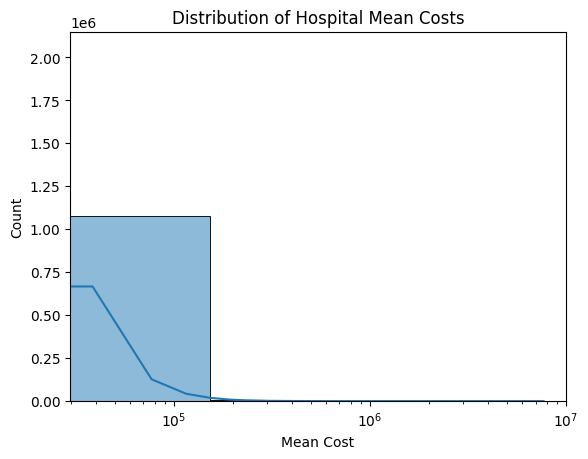

In [18]:
# 2. What is the distribution of hospital costs for inpatient procedures?

# Here I used HistPlot

sns.histplot(df['Mean Cost'], bins = 50, kde= True)
plt.xscale('log')
plt.title("Distribution of Hospital Mean Costs")
plt.savefig("002.Distribution_of_Hospital_Mean_Costs.png")

In [19]:
# 3. Which diagnosis categories appear most frequently in hospital discharges? for this we took top 10

# Here first we count the values of each by according to the 'APR DRG Description'

count_value = df['APR DRG Description'].value_counts().head(10)
count_value = count_value.reset_index()
count_value

,APR DRG Description,count
0,Diabetes,6271
1,Other Pneumonia,6126
2,Chronic Obstructive Pulmonary Disease,6010
3,Heart Failure,5971
4,Seizure,5908
5,Kidney & Urinary Tract Infections,5855
6,Cellulitis & Other Bacterial Skin Infections,5815
7,Cardiac Arrhythmia & Conduction Disorders,5793
8,Septicemia & Disseminated Infections,5770
9,Other Anemia & Disorders Of Blood & Blood-Form...,5602


C:\Users\dhamm\AppData\Local\Temp\ipykernel_17964\1252779773.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = count_value,x = 'APR DRG Description', y = 'count', palette = 'Set2')


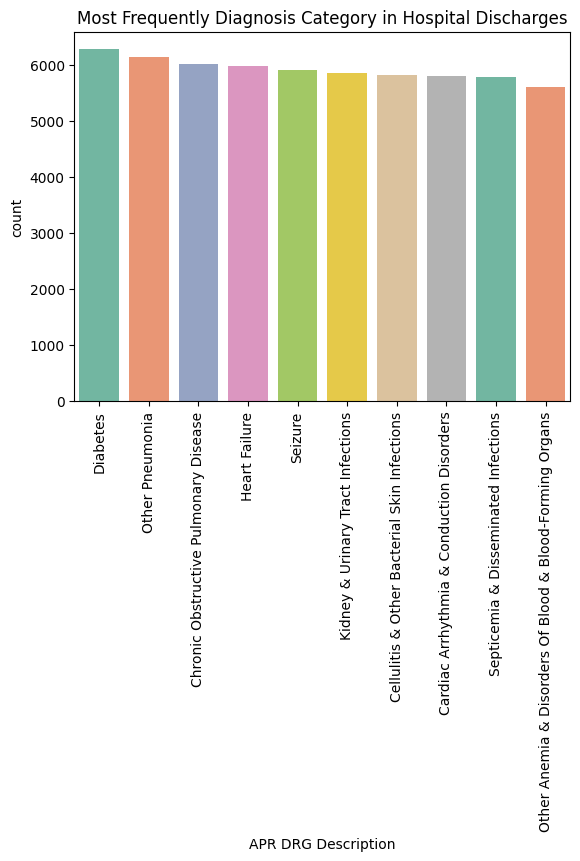

In [20]:
# 3. Which diagnosis categories appear most frequently in hospital discharges? for this we took top 10

# Here I used BarPlot

sns.barplot(data = count_value,x = 'APR DRG Description', y = 'count', palette = 'Set2')
plt.xticks(rotation = 90) 
plt.title("Most Frequently Diagnosis Category in Hospital Discharges")
plt.savefig("003.Most_Frequetly_Diagnosis_Category_in_Hospital_Discharges.png")

In [21]:
# 4. What is the distribution of patient discharge volumes across hospitals?

# Here we first group the data with 'Facility Name' with respect to 'Discharges' and then sum and sort values.

count_Hospitals = df.groupby('Facility Name')['Discharges'].sum().sort_values()
count_Hospitals = count_Hospitals.reset_index()
count_Hospitals


,Facility Name,Discharges
0,The University of Vermont Health Network-Eliza...,14
1,Rockefeller University Hospital,53
2,Monroe Community Hospital,166
3,Albany Medical Center - South Clinical Campus,235
4,TLC Health Network Tri-County Memorial Hospital,512
...,...,...
277,Maimonides Medical Center,389707
278,New York Presbyterian Hospital - New York Weil...,411728
279,New York Presbyterian Hospital - Columbia Pres...,443565
280,North Shore University Hospital,459402


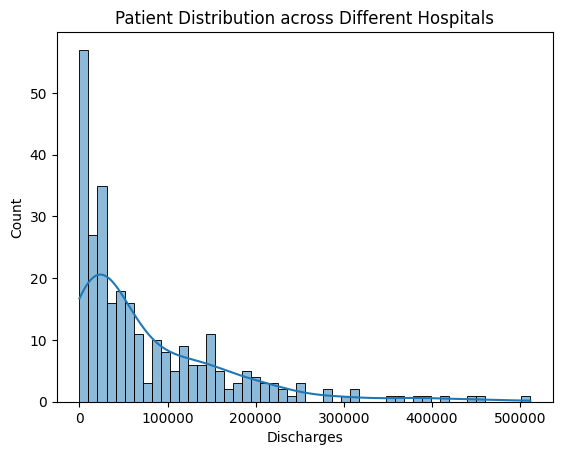

In [22]:
# 4. What is the distribution of patient discharge volumes across hospitals?

# Here I used HistPlot

sns.histplot(count_Hospitals['Discharges'], bins = 50, kde = True)
plt.title("Patient Distribution across Different Hospitals")
plt.savefig("004.Patient_Distribution_acorss_Different_Hospitals.png")


In [23]:
# 5. How are severity levels of illness distributed among hospital patients?

# We performed Grouping of 'APR Severity of Illness Description' with 'Discharges' and sum the values and after that dropped 2 columns.

count_variables = df.groupby('APR Severity of Illness Description')['Discharges'].sum()
count_variable = count_variables.drop(['Not Applicable','Not Present'])
count_variable

APR Severity of Illness Description
Extreme     1332708
Major       4685457
Minor       7875059
Moderate    8343861
Name: Discharges, dtype: int64

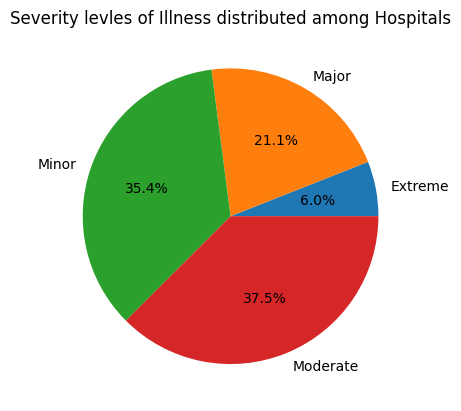

In [24]:
# 5. How are severity levels of illness distributed among hospital patients?

# Here I used Pie Chart

piechart = plt.pie(count_variable, labels = count_variable.index, autopct= '%1.1f%%')
plt.title("Severity levles of Illness distributed among Hospitals")
plt.savefig("005.Sevierity_Levels_of_Illness_Distributed_among_Hospitals.png")


## 🔍 Bivariate Analysis

Bivariate analysis examines **relationships between two variables**.

Examples include:

- How does severity of illness affect hospital charges?
- What is the relationship between number of discharges and hospital charges?
- How do medical vs surgical treatments differ in average charges?
- Which diagnoses generate the highest hospital costs?
- How do hospital costs vary across different healthcare facilities?

This analysis helps identify **relationships affecting hospital costs.**

In [25]:
# Bivariate Analysis

# 1. How does severity of illness affect hospital charges?

# Here we grouped the 'APR Severity of Illness Description' with 'Mean Charge' and perform the sum operation.

Total_Charges = count_variables = df.groupby('APR Severity of Illness Description')['Mean Charge'].sum()
Total_Charges = Total_Charges.drop(['Not Applicable','Not Present'])
Total_Charges = Total_Charges.reset_index()
Total_Charges


,APR Severity of Illness Description,Mean Charge
0,Extreme,20700410011.20
1,Major,15939636261.54
2,Minor,6550886731.39
3,Moderate,10687364552.46


C:\Users\dhamm\AppData\Local\Temp\ipykernel_17964\1661813141.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = Total_Charges, x = 'APR Severity of Illness Description', y = 'Mean Charge',palette= 'deep')


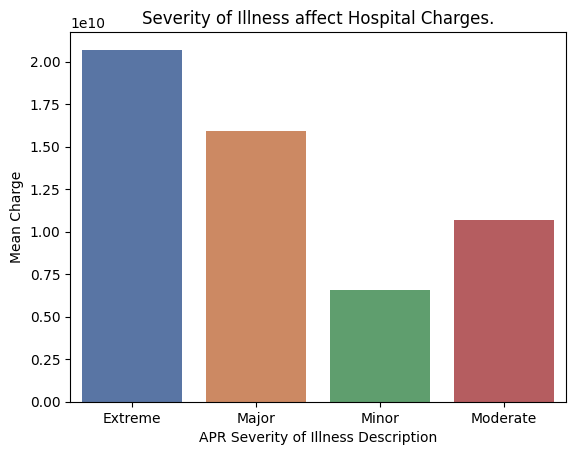

In [26]:
# 1. How does severity of illness affect hospital charges?

# Here I used BarPlot

sns.barplot(data = Total_Charges, x = 'APR Severity of Illness Description', y = 'Mean Charge',palette= 'deep')
plt.title("Severity of Illness affect Hospital Charges.")
plt.savefig("006.Severity_of_Illness_affect_Hospital_Charges.png")

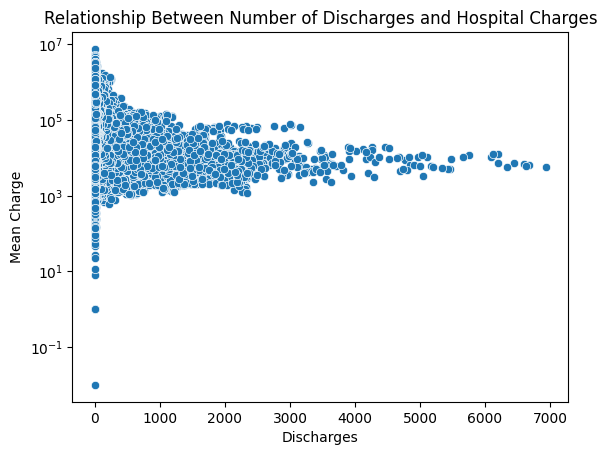

In [27]:
# 2. What is the relationship between number of discharges and hospital charges?

sns.scatterplot(data = df, x = 'Discharges', y = 'Mean Charge')
plt.yscale('log')
plt.title("Relationship Between Number of Discharges and Hospital Charges")
plt.savefig("007.Relationship_Between_Number_of_Discharges_and_Hospital_Charges.png")


In [28]:
# 3. How do medical vs surgical treatments differ in average charges?

# Here I grouped the data by 'Year' and 'APR Medical description' with 'Mean Charge' and perform sum operation

Mean_Charges_Year = filtered_data.groupby(['Year','APR Medical Surgical Description'])['Mean Charge'].sum()
Mean_Charges_Years = Mean_Charges_Year.reset_index()
Mean_Charges_Years


,Year,APR Medical Surgical Description,Mean Charge
0,2009,Medical,2578646674.00
1,2009,Surgical,2483402909.00
2,2010,Medical,2660408036.00
3,2010,Surgical,2516950061.00
4,2011,Medical,2712198833.06
5,2011,Surgical,2595633010.21
6,2012,Medical,2781619529.42
7,2012,Surgical,2660069703.68
8,2013,Medical,3054267486.90
9,2013,Surgical,2886798527.09


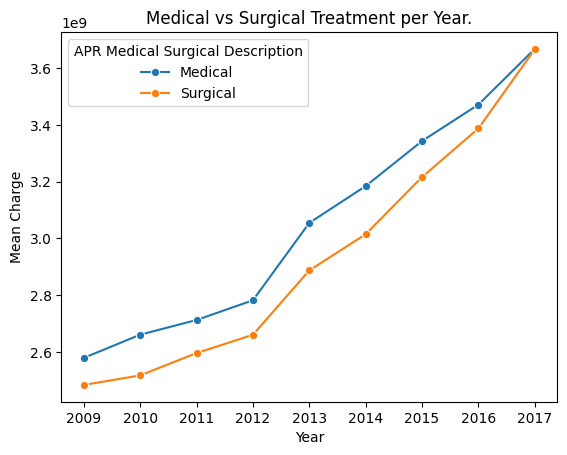

In [29]:
# 3. How do medical vs surgical treatments differ in average charges?

# Here I used linePlot

sns.lineplot(data = Mean_Charges_Years, x = 'Year', y = 'Mean Charge',hue = 'APR Medical Surgical Description', marker = 'o')
plt.title("Medical vs Surgical Treatment per Year.")
plt.savefig('008.Medical_vs_Surgical_Treatments_Per_Year.png')

In [30]:
# 4. Which diagnoses generate the highest hospital costs?

# Here I grouped the data on 'APR DRG Description' with respect to 'Mean Cost' and perform sum operation.

Groupped_Diagnosis = df.groupby('APR DRG Description')['Mean Cost'].sum().head(10).sort_values(ascending=False)
Groupped_Diagnosis = Groupped_Diagnosis.reset_index()
Groupped_Diagnosis



,APR DRG Description,Mean Cost
0,Acute Leukemia,75031639.87
1,Acute Myocardial Infarction,63135957.50
2,Acute & Subacute Endocarditis,52802471.28
3,Abdominal Pain,31326302.19
4,Acute Anxiety & Delirium States,24346188.01
5,Acute Major Eye Infections,19474713.19
6,Acute Kidney Injury,10075333.12
7,Acute & subacute endocarditis,6926060.43
8,Abdominal pain,3719110.29
9,Acute anxiety & delirium states,3542494.99


C:\Users\dhamm\AppData\Local\Temp\ipykernel_17964\4268176506.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = Groupped_Diagnosis, x = 'APR DRG Description', y = 'Mean Cost', palette = 'dark')


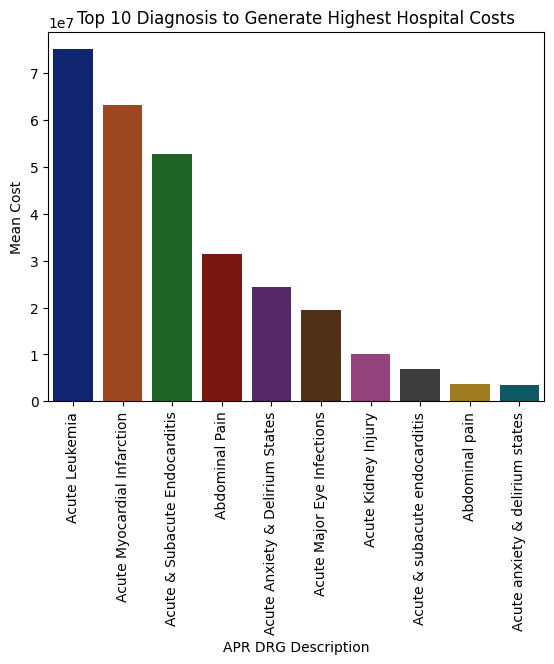

In [31]:
# 4. Which diagnoses generate the highest hospital costs?

# Here I used BarPlot

sns.barplot(data = Groupped_Diagnosis, x = 'APR DRG Description', y = 'Mean Cost', palette = 'dark')
plt.xticks(rotation = 90)
plt.title("Top 10 Diagnosis to Generate Highest Hospital Costs")
plt.savefig("009.Top_10_Diagnosis_to_Generate_Highest_Hospital_Costs.png")

In [32]:
# 5. How do hospital costs vary across different healthcare facilities?

# Here I grouped the data by 'Facility Name' with respect to 'Mean Cost' and perform sum operation.

Groupby_Cost = df.groupby('Facility Name')['Mean Cost'].sum().sort_values(ascending= False)
Groupby_Costs = Groupby_Cost.reset_index()
Groupby_Costs = Groupby_Costs.head(10)
Groupby_Costs

,Facility Name,Mean Cost
0,New York Presbyterian Hospital - Columbia Pres...,425940028.31
1,Westchester Medical Center,413515131.85
2,New York Presbyterian Hospital - New York Weil...,393568455.60
3,Mount Sinai Hospital,346353222.98
4,Montefiore Medical Center - Henry & Lucy Moses...,329472423.83
5,University Hospital,322796921.99
6,University Hospital of Brooklyn,319385593.50
7,Kings County Hospital Center,290045645.57
8,Bellevue Hospital Center,263912506.43
9,Jacobi Medical Center,260293609.25


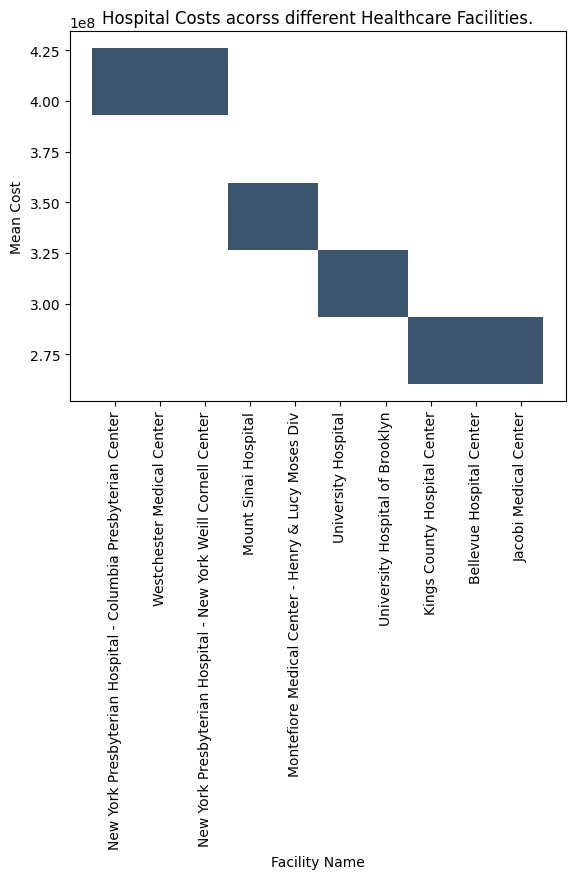

In [33]:
# 5. How do hospital costs vary across different healthcare facilities?

# Here I used HistPlot

sns.histplot(data = Groupby_Costs, x = 'Facility Name', y = 'Mean Cost')
plt.xticks(rotation = 90)
plt.title("Hospital Costs acorss different Healthcare Facilities.")
plt.savefig("010.Hospital_Costs_across_different_Healthcare_Facilities.png")

## 💰 Hospital Cost Analysis

Hospital treatment costs vary based on multiple factors including:

- Which diagnosis have the highest average hospital charges?
- Which hospitals report the highest treatment costs?
- How do charges compare to actual hospital costs?
- Which severity level results in the highest hospital treatment cost?
- Which medical or surgical procedures contribute most to hospital expenses?

This section identifies **the major contributors to high healthcare costs.**

In [34]:
# 1. Which diagnosis have the highest average hospital charges?

# Here I am groupping the data according to 'APR DRG Description' with respect to 'Mean Charge' and perform mean operation

mean_operation = df.groupby('APR DRG Description')['Mean Charge'].mean().round(2).sort_values(ascending=False)
mean_operation = mean_operation.head(5).reset_index()
mean_operation

,APR DRG Description,Mean Charge
0,Neonate w ECMO,1405886.71
1,Heart &/or lung transplant,1125730.55
2,Neonate bwt <1500g w major procedure,902165.56
3,Neonate Bwt <1500G W Major Procedure,763735.71
4,Neonate W Ecmo,747117.74


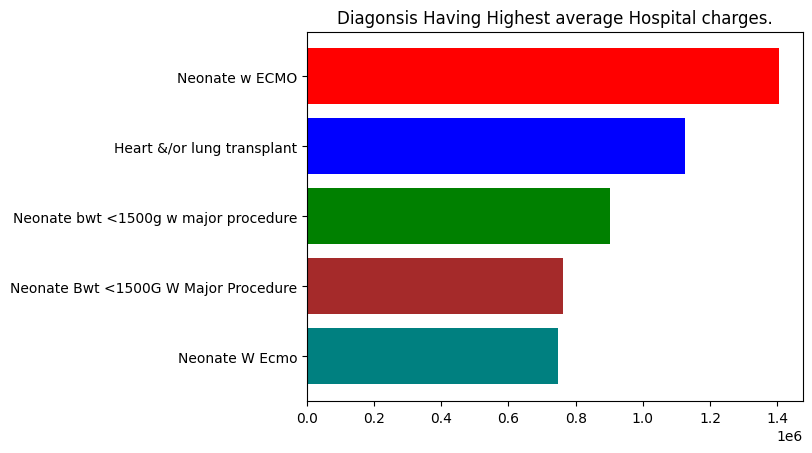

In [35]:
# 1. Which diagnosis have the highest average hospital charges?

# Here I used horiontal barchart

colors = ['red','blue','green','brown','teal']

plt.barh(data = mean_operation, y = 'APR DRG Description', width = 'Mean Charge',color = colors)
plt.gca().invert_yaxis()
plt.title("Diagonsis Having Highest average Hospital charges.")
plt.savefig("011.Diagonsis_Having_Higest_Average_Hospital_Charges.png")

In [36]:
# 2. Which hospitals report the highest treatment costs?

# Here we will group the data by 'Facility names' with respect to 'Mean Cost' and perform sum operations.

highest_treatment_cost = df.groupby('Facility Name')['Mean Cost'].sum().sort_values(ascending=False).head(10)
highest_treatment_cost = highest_treatment_cost.reset_index()
highest_treatment_cost

,Facility Name,Mean Cost
0,New York Presbyterian Hospital - Columbia Pres...,425940028.31
1,Westchester Medical Center,413515131.85
2,New York Presbyterian Hospital - New York Weil...,393568455.60
3,Mount Sinai Hospital,346353222.98
4,Montefiore Medical Center - Henry & Lucy Moses...,329472423.83
5,University Hospital,322796921.99
6,University Hospital of Brooklyn,319385593.50
7,Kings County Hospital Center,290045645.57
8,Bellevue Hospital Center,263912506.43
9,Jacobi Medical Center,260293609.25


C:\Users\dhamm\AppData\Local\Temp\ipykernel_17964\117768204.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = highest_treatment_cost, x  = 'Facility Name', y = 'Mean Cost', palette= 'dark')


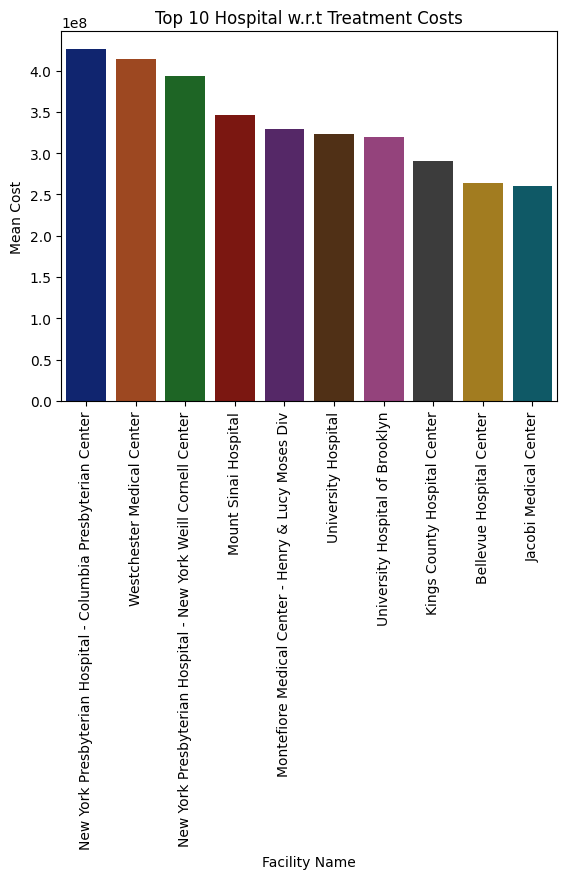

In [37]:
# 2. Which hospitals report the highest treatment costs?

# Here I will be using BarPlot

sns.barplot(data = highest_treatment_cost, x  = 'Facility Name', y = 'Mean Cost', palette= 'dark')
plt.xticks(rotation = 90)
plt.title("Top 10 Hospital w.r.t Treatment Costs")
plt.savefig("012.Top_10_Hospital_with_Highest_Treatment_Costs.png")

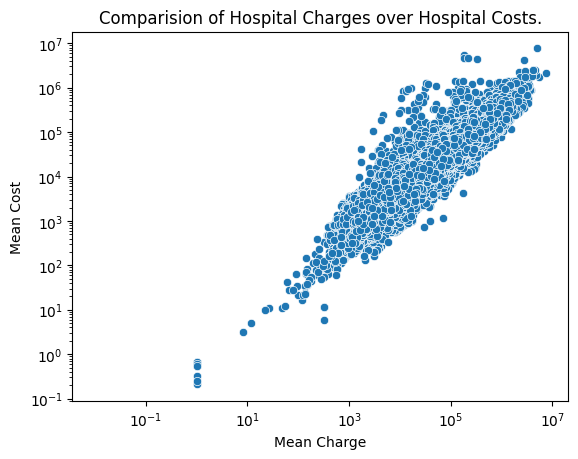

In [38]:
# 3. How do charges compare to actual hospital costs?

# Here I am ScatterPlot

sns.scatterplot(data = df, x = 'Mean Charge', y = 'Mean Cost')
plt.xscale('log')
plt.yscale('log')
plt.title("Comparision of Hospital Charges over Hospital Costs.")
plt.savefig("013.Comparision_of_Hospital_Charges_over_Hospital_Costs.png")


In [39]:
# 4. Which severity level results in the highest hospital treatment cost?

# Here first we grouped the Hospital Mean Cost according to the severity level

severity_level = df.groupby('APR Severity of Illness Description')['Mean Cost'].sum().sort_values(ascending= False)
severity_level = severity_level.drop('Not Applicable')
severity_level = severity_level.reset_index()
severity_level

,APR Severity of Illness Description,Mean Cost
0,Extreme,7595936834.81
1,Major,5918937442.16
2,Moderate,4007701960.52
3,Minor,2470729064.14
4,Not Present,8159980.05


C:\Users\dhamm\AppData\Local\Temp\ipykernel_17964\3108347852.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = severity_level, x = 'APR Severity of Illness Description', y = 'Mean Cost',palette='dark')


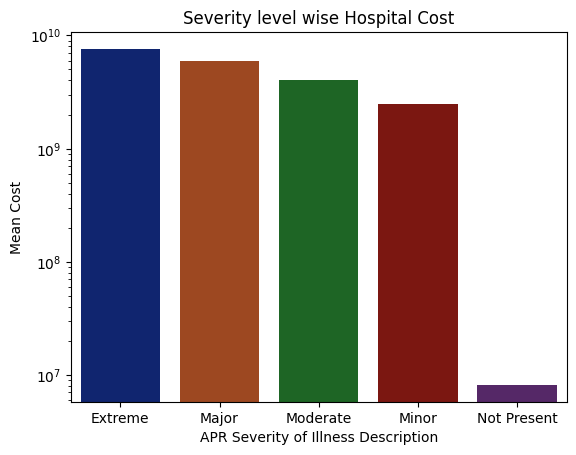

In [40]:
# 4. Which severity level results in the highest hospital treatment cost?

# Here I am using BarPlot

sns.barplot(data = severity_level, x = 'APR Severity of Illness Description', y = 'Mean Cost',palette='dark')
plt.yscale('log')
plt.title("Severity level wise Hospital Cost")
plt.savefig("014.Severity_levle_wise_Hospital_Cost.png")

In [41]:
# 5. Which medical or surgical procedures contributes most to hospital expenses?

# Here we will group the data according to 'APR Medical Surgical Description' with 'Mean Costs'

Hospital_expenses = df.groupby('APR Medical Surgical Description')['Mean Cost'].sum().sort_values(ascending=False)
Hospital_expenses = Hospital_expenses.drop('Other')
Hospital_expenses = Hospital_expenses.reset_index()
Hospital_expenses

,APR Medical Surgical Description,Mean Cost
0,Medical,10042606990.86
1,Surgical,9950698310.77


C:\Users\dhamm\AppData\Local\Temp\ipykernel_17964\3386844778.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = Hospital_expenses, x = 'APR Medical Surgical Description', y = 'Mean Cost',palette=('Red','teal'))


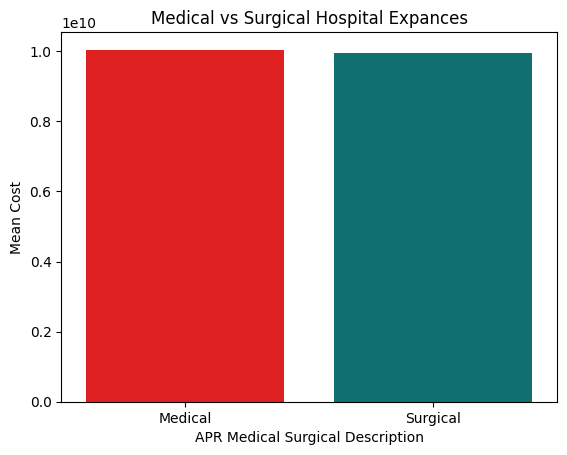

In [42]:
# 5. Which medical or surgical procedures contributes most to hospital expenses?

# Here I am using BarPlot

sns.barplot(data = Hospital_expenses, x = 'APR Medical Surgical Description', y = 'Mean Cost',palette=('Red','teal'))
plt.title("Medical vs Surgical Hospital Expances")
plt.savefig("015.Medical_vs_Surgical_Hospital_Expances.png")

## 🏨 Patient Resource Utilization


Hospital resources such as:

- Which hospitals handle the highest number of patient discharges?
- Which diagnoses account for the largest patient volumes?
- How does severity of illness impact hospital resource utilization?
- Do hospitals with higher patient volumes have higher or lower treatment charges?

are limited and must be efficiently managed.

This section analyzes how patient treatments impact **hospital resource utilization.**

In [43]:
# 1. Which hospital handle the highest number of patient discharges?

# Here I am grouped the data according to 'Facility Name' with sum of 'Discharge'

Patient_Discharge = df.groupby('Facility Name')['Discharges'].sum().sort_values(ascending=False).head(10)
Patient_Discharge = Patient_Discharge.reset_index()
Patient_Discharge

,Facility Name,Discharges
0,Mount Sinai Hospital,511828
1,North Shore University Hospital,459402
2,New York Presbyterian Hospital - Columbia Pres...,443565
3,New York Presbyterian Hospital - New York Weil...,411728
4,Maimonides Medical Center,389707
5,Montefiore Medical Center - Henry & Lucy Moses...,387327
6,Strong Memorial Hospital,365987
7,Long Island Jewish Medical Center,356777
8,University Hospital,315539
9,Albany Medical Center Hospital,314144


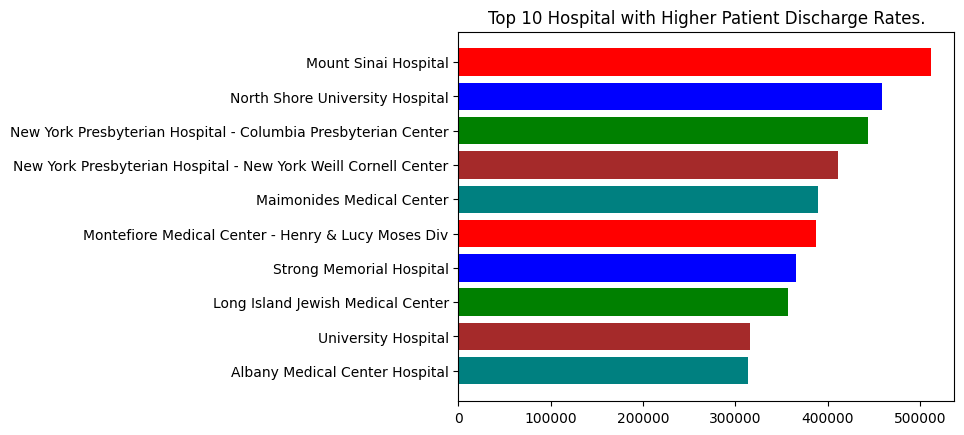

In [44]:
# 1. Which hospital handle the highest number of patient discharges?

# Here Iam using horizontal Barplot

colors = ['red','blue','green','brown','teal']

plt.barh(data = Patient_Discharge, y = 'Facility Name', width = 'Discharges', color = colors)
plt.gca().invert_yaxis()
plt.title("Top 10 Hospital with Higher Patient Discharge Rates.")
plt.savefig("016.Top_10_Hospital_with_Higer_Patient_Discharge_Rates.png")

In [45]:
# 2. Which diagnosis account for the largest patient volumns?

# Here I am going to group the data according to 'APR DRG Description' with respect to 'Discharges' and perform sum operation

diagnosis_count = df.groupby('APR DRG Description')['Discharges'].sum().sort_values(ascending= False).head(10)
diagnosis_count = diagnosis_count.reset_index()
diagnosis_count

,APR DRG Description,Discharges
0,"Neonate Birthwt >2499G, Normal Newborn Or Neon...",1641587
1,Vaginal Delivery,1196321
2,Cesarean Delivery,630604
3,Septicemia & Disseminated Infections,575841
4,Heart Failure,449370
5,Other Pneumonia,385419
6,Chronic Obstructive Pulmonary Disease,359150
7,Schizophrenia,314008
8,Cellulitis & Other Bacterial Skin Infections,309983
9,Cardiac Arrhythmia & Conduction Disorders,293906


C:\Users\dhamm\AppData\Local\Temp\ipykernel_17964\1617061237.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = diagnosis_count, x = 'APR DRG Description',y = 'Discharges',palette='dark')


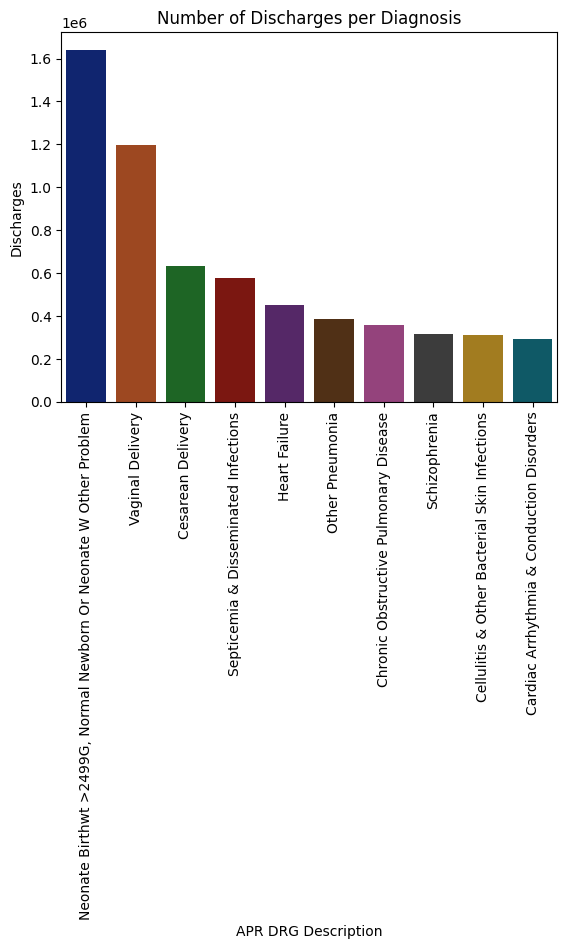

In [46]:
# 2. Which diagnosis account for the largest patient volumns?

# Here I am using countPlot

sns.barplot(data = diagnosis_count, x = 'APR DRG Description',y = 'Discharges',palette='dark')
plt.xticks(rotation = 90)
plt.title("Number of Discharges per Diagnosis")
plt.savefig('017.Number_of_Discharges_per_Diagnosis.png')

In [47]:
# 3. How does severity of illness impact hospital resource utilization?

# Here I am groupping the data according to the severity of illness 

severity_level

,APR Severity of Illness Description,Mean Cost
0,Extreme,7595936834.81
1,Major,5918937442.16
2,Moderate,4007701960.52
3,Minor,2470729064.14
4,Not Present,8159980.05


C:\Users\dhamm\AppData\Local\Temp\ipykernel_17964\3524390801.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = severity_level, x = 'APR Severity of Illness Description', y = 'Mean Cost', palette='dark')


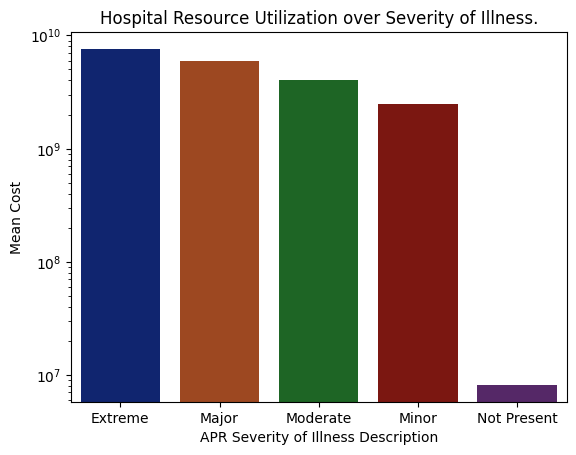

In [48]:
sns.barplot(data = severity_level, x = 'APR Severity of Illness Description', y = 'Mean Cost', palette='dark')
plt.yscale('log')
plt.title("Hospital Resource Utilization over Severity of Illness.")
plt.savefig("018.Hospital_Resource_Utilization_over_Severity_of_Illness.png")

In [49]:
# 4. Do Hospitals with higher patient volumnes have higher or lower treatment charges?

# Here first we group the data with 'Facility Name' with respect to 'Discharges' and 'Mean Cost' and perform sum operation

Patient_Treatment_cost = df.groupby('Facility Name').agg({'Discharges': 'sum','Mean Cost':'mean'})
Patient_Treatment_cost = Patient_Treatment_cost.sort_values(by = 'Discharges',ascending=False).head(10)
Patient_Treatment_cost

,Discharges,Mean Cost
Facility Name,,
Mount Sinai Hospital,511828,34611.09
North Shore University Hospital,459402,23486.07
New York Presbyterian Hospital - Columbia Presbyterian Center,443565,42068.15
New York Presbyterian Hospital - New York Weill Cornell Center,411728,39250.87
Maimonides Medical Center,389707,24868.59
Montefiore Medical Center - Henry & Lucy Moses Div,387327,35933.30
Strong Memorial Hospital,365987,24541.51
Long Island Jewish Medical Center,356777,20318.95
University Hospital,315539,33350.23


C:\Users\dhamm\AppData\Local\Temp\ipykernel_17964\2472319858.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = Patient_Treatment_cost, x = 'Facility Name', y = 'Discharges',palette='dark', ax = axes1)


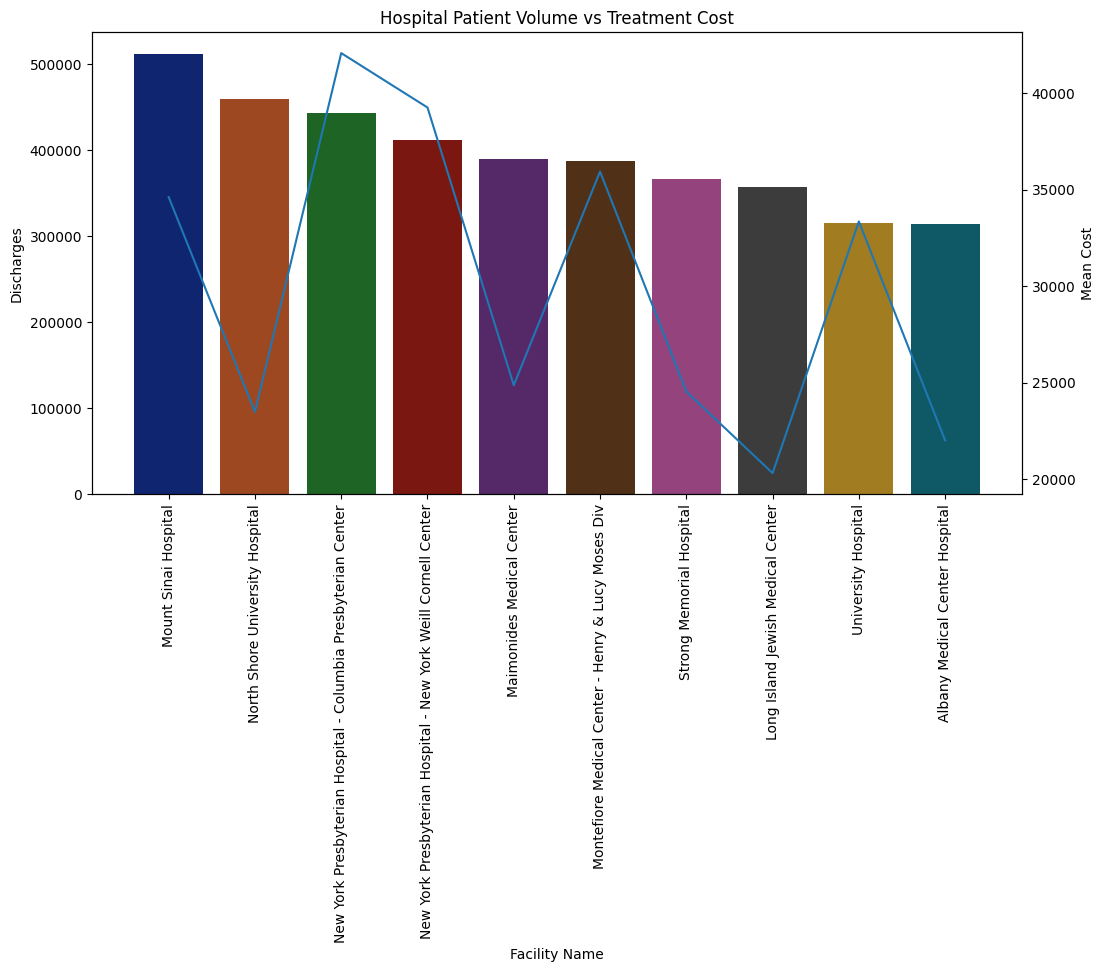

In [50]:
# 4. Do Hospitals with higher patient volumnes have higher or lower treatment charges?

# Here I am going to use two plots 1st BarPlot for 'Discharges' and 2nd LinePlot for mean Cost

fig, axes1 = plt.subplots(figsize = (12,6))

# Bar Plot for Discharges

sns.barplot(data = Patient_Treatment_cost, x = 'Facility Name', y = 'Discharges',palette='dark', ax = axes1)
plt.xticks(rotation = 90)

axes2 = axes1.twinx()
sns.lineplot(data = Patient_Treatment_cost, x = 'Facility Name', y = 'Mean Cost',markers='o',ax = axes2)

plt.title("Hospital Patient Volume vs Treatment Cost")
plt.savefig("019.Hospital_Patient_Volume_vs_Treatment_Cost.png")

## 💡 Key Insights


From the exploratory analysis, we aim to identify:

1️⃣ The dataset contains 1,081,672 hospital discharge records across 14 variables, providing large-scale insights into hospital costs and patient resource utilization.

2️⃣ A few hospitals handle the highest patient volumes, with Mount Sinai Hospital recording 511,828 discharges, followed by North Shore University Hospital (459,402) and New York Presbyterian – Columbia (443,565).

3️⃣ Severity of illness significantly impacts treatment costs, with Extreme severity cases showing the highest mean treatment cost compared to Minor and Moderate cases.

4️⃣ A substantial gap exists between hospital charges and actual treatment costs, indicating that hospitals bill patients significantly higher than the underlying treatment cost.

5️⃣ Patient volumes are unevenly distributed across hospitals, where large hospitals manage hundreds of thousands of discharges, while smaller facilities handle considerably fewer cases.

These insights can help healthcare systems **optimize costs and improve operational efficiency.**

## 📌 Conclusion


This Exploratory Data Analysis examined hospital treatment costs and patient resource utilization using over 1.08 million inpatient records from New York hospitals.

The findings can help healthcare organizations:

✔ Healthcare services are concentrated in a few major hospitals, with institutions like Mount Sinai Hospital handling more than 500,000 patient discharges.

✔ Severity of illness is one of the strongest drivers of hospital cost, with Extreme severity cases producing the highest treatment costs.

✔ There is a significant gap between hospital charges and actual treatment costs, indicating that hospital billing structures include substantial markups.

✔ Higher patient volume does not automatically lead to higher treatment costs, suggesting that operational efficiency and hospital specialization play important roles in cost management.

Future analysis could include **predictive modeling for hospital costs and patient outcomes.**